<a href="https://colab.research.google.com/github/haze25102583/CNN/blob/main/cnn1_1_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ANN: 이미지를 펼침
# CNN: 공간 구조를 활용

In [9]:
# 1. 실습 환경과 재현성 설정

import os
import random
import time
import numpy as np
import pandas as pd

# 그래프와 평가 도구
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# 딥러닝 모델: TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 실습 결과 재현: 공통 난수 시드
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 빠른 실행 모드
FAST_MODE = True
EPOCHS = 4 if FAST_MODE else 10
BATCH_SIZE = 128

# 현재 실행 환경, 설정 확인
print("TensorFlow: ", tf.__version__)
print("GPU: ", tf.config.list_physical_devices("GPU"))
print("FAST_MODE / EPOCHS: ", FAST_MODE, EPOCHS)

TensorFlow:  2.20.0
GPU:  []
FAST_MODE / EPOCHS:  True 4


In [10]:
# 2. Fashion-MNIST
#   28x28 흑백 의류 이미지 10종 분류하는 데이터
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = np.array([
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
])

# 원본 배열 -> 크기, 자료형 ?
print("train images: ", x_train_full.shape, x_train_full.dtype)
print("train labels: ", y_train_full.shape, y_train_full.dtype)
print("test images: ", x_test_full.shape, x_test_full.dtype)
print("pixel range: ", x_train_full.min(), "~", x_train_full.max())

train images:  (60000, 28, 28) uint8
train labels:  (60000,) uint8
test images:  (10000, 28, 28) uint8
pixel range:  0 ~ 255


In [11]:
# 데이터 계약: 모델에 넣기 전 입력&정답의 shape, 클래스 수
assert x_train_full.ndim == 3
assert x_train_full.shape[1:] == (28, 28)

assert y_train_full.ndim == 1
assert len(x_train_full) == len(y_train_full)
assert set(np.unique(y_train_full)) == set(range(10))

# 각 클래스의 개수를 표로 확인 -> 심한 불균형이 있나 확인
class_counts = pd.Series(y_train_full).value_counts().sort_index()
contract = pd.DataFrame({
    "class_id": np.arange(10),              # range - 정수, arange - 실수
    "class_name": CLASS_NAMES,
    "train_count": class_counts.values,
})
display(contract)

,class_id,class_name,train_count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


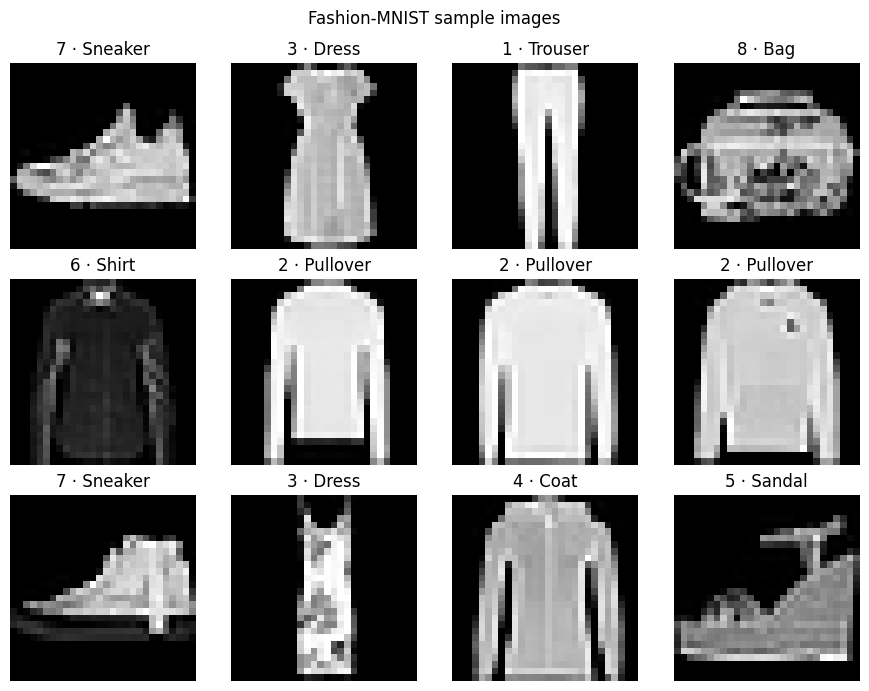

In [12]:
# Random Number Generator
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(x_train_full), size=12, replace=False)        # 랜덤으로 샘플 추출. replace -> 중복 허용 여부

fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for ax, idx in zip(axes.ravel(), sample_indices):                             # ravel(): 행렬을 펼침
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(f"{y_train_full[idx]} · {CLASS_NAMES[y_train_full[idx]]}")
    ax.axis("off")

plt.suptitle("Fashion-MNIST sample images")
plt.tight_layout()
plt.show()

In [14]:
if FAST_MODE:
    x_work, _, y_work, _ = train_test_split(
        x_train_full, y_train_full, train_size=15_000,
        stratify=y_train_full, random_state=SEED,
    )

    x_test_raw, _, y_test, _ = train_test_split(
        x_test_full, y_test_full,
        train_size=3_000, stratify=y_test_full, random_state=SEED,
    )

else:
    x_work, y_work = x_train_full, y_train_full
    x_test_raw, y_test = x_test_full, y_test_full

x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    x_work, y_work,
    test_size=0.2, stratify=y_work, random_state=SEED,
)

print("train: ", x_train_raw.shape, y_train.shape)
print("valid: ", x_val_raw.shape, y_val.shape)
print("test : ", x_test_raw.shape, y_test.shape)


train:  (12000, 28, 28) (12000,)
valid:  (3000, 28, 28) (3000,)
test :  (3000, 28, 28) (3000,)


In [ ]:
# 255.0으로 나누어 픽셀 범위를 0~1로 정규화
x_train_raw = x_train_raw.astype("float32") / 255.0
x_val_raw = x_val_raw.astype("float32") / 255.0
x_test_raw = x_test_raw.astype("float32") / 255.0

x_train_ann = x_train_raw
x_val_ann = x_val_raw
